# Stage 8 — Training

> **Spec §8** — Full training loop with mixed-precision AMP, AdamW, CosineAnnealingLR, early stopping, and checkpoint saving.

This notebook trains the ResNet-18 real/bogus classifier on the preprocessed ZTF data and visualises the training dynamics.  The trained model is saved to `checkpoints/` and reused in the evaluation notebook.

**Sections**
1. Imports & setup
2. DataLoaders
3. Training loop walkthrough
4. Train — ResNet-18 real/bogus (full run)
5. Training curves
6. Checkpoint verification
7. Quick sanity eval on val set
8. Summary

## 0 — Imports & Setup

In [8]:
import sys, warnings, json, time
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader

from src.models import RealBogusResNet18, build_model
from src.losses import FocalLoss, build_loss
from src.dataset import build_datasets, make_weighted_sampler
from src.train import train, train_epoch, evaluate_rb, load_checkpoint
from src.evaluate import plot_training_curves, full_eval_rb

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path('..').resolve()
LABELS_CSV   = PROJECT_ROOT / 'data' / 'labels.csv'
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
PROCESSED      = PROJECT_ROOT / 'data' / 'processed'

CKPT_DIR    = Path('../checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.2 GB


## 1 — DataLoaders

Load the preprocessed `.npy` triplets and build PyTorch DataLoaders. Training uses `WeightedRandomSampler` (spec §7 Strategy 2) + `FocalLoss` (Strategy 1).

In [9]:
df = pd.read_csv(LABELS_CSV)
train_ds, val_ds, test_ds = build_datasets(
    df, task='real_bogus', processed_dir=PROCESSED
)

BATCH_SIZE = 64
N_WORKERS  = 4

sampler = make_weighted_sampler(train_ds.labels)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=N_WORKERS, pin_memory=DEVICE.type=='cuda',
    persistent_workers=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=DEVICE.type=='cuda',
    persistent_workers=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=DEVICE.type=='cuda',
    persistent_workers=True,
)

print(f'Train: {len(train_ds):,} samples  |  {len(train_loader):,} batches')
print(f'Val:   {len(val_ds):,} samples  |  {len(val_loader):,} batches')
print(f'Test:  {len(test_ds):,} samples  |  {len(test_loader):,} batches')

# Show one batch shape
x_sample, y_sample = next(iter(train_loader))
print(f'Batch x shape: {tuple(x_sample.shape)}  dtype: {x_sample.dtype}')
print(f'Batch y shape: {tuple(y_sample.shape)}  unique labels: {y_sample.unique().tolist()}')

Train: 91,889 samples  |  1,436 batches
Val:   19,690 samples  |  308 batches
Test:  19,691 samples  |  308 batches
Batch x shape: (64, 3, 63, 63)  dtype: torch.float32
Batch y shape: (64,)  unique labels: [0, 1]


## 2 — Training Loop Walkthrough

The training loop in `src/train.py` follows spec §8 exactly:

```
for epoch in range(epochs):
    train_epoch(model, loader, optimizer, criterion, scaler)  # AMP
    evaluate_rb(model, val_loader)                            # AUC + AP
    scheduler.step()                                          # CosineAnnealingLR
    if val_auc > best:  save_checkpoint()
    if no_improve >= patience:  break  # early stopping
```

Key choices:
| Component | Choice | Reason |
|-----------|--------|--------|
| Optimiser | AdamW (lr=1e-3, wd=1e-4) | Spec §8; AdamW > Adam for generalisation |
| Scheduler | CosineAnnealingLR (T_max=50) | Smooth LR decay without warmup |
| Loss | FocalLoss (alpha=0.25, gamma=2.0) | Handles class imbalance (spec §7) |
| Precision | FP16 AMP | RTX 4060 efficient at FP16 |
| Grad clip | 1.0 | Stability with focal loss |
| Patience | 8 epochs | Avoid over-training on small bogus set |

## 3 — Train ResNet-18 Real/Bogus

Full training run.  Progress is printed every epoch. The best model is saved to `checkpoints/resnet18_rb_best.pt`.

> **Note:** This cell takes ~20-60 min on an RTX 4060 depending on epochs. A pre-trained checkpoint is used automatically in the evaluation notebook if it already exists.

In [10]:
EPOCHS   = 50
LR       = 1e-3
RUN_NAME = 'resnet18_rb'

# Check if checkpoint already exists
ckpt_path = CKPT_DIR / f'{RUN_NAME}_best.pt'
if ckpt_path.exists():
    print(f'Checkpoint already exists: {ckpt_path}')
    print('Loading existing history if available...')
    hist_path = CKPT_DIR / f'{RUN_NAME}_history.json'
    if hist_path.exists():
        history_data = json.loads(hist_path.read_text())
        print(f'  History: {len(history_data)} epochs  '
              f'best_auc={max(h["val_auc"] for h in history_data):.4f}')
    history_result = None  # will be loaded below
else:
    import logging
    logging.basicConfig(level=logging.INFO, format='%(message)s')

    model_rb = RealBogusResNet18()
    criterion = FocalLoss(alpha=0.25, gamma=2.0)

    history_result = train(
        model        = model_rb,
        train_loader = train_loader,
        val_loader   = val_loader,
        criterion    = criterion,
        task         = 'real_bogus',
        epochs       = EPOCHS,
        lr           = LR,
        device       = DEVICE,
        checkpoint_dir = CKPT_DIR,
        run_name     = RUN_NAME,
        patience     = 8,
    )
    print(f'\nTraining complete!')
    print(f'Best epoch: {history_result["best_epoch"]}  '
          f'Best val AUC: {history_result["best_metric"]:.4f}')

Training resnet18_rb | device=cuda | epochs=50 | lr=0.001 | loss=FocalLoss
Epoch   1 | train_loss=0.0118 | val_auc=0.9962 | lr=9.99e-04
  ✓ New best 0.9962 — saved to ../checkpoints/resnet18_rb_best.pt
Epoch   2 | train_loss=0.0066 | val_auc=0.9948 | lr=9.96e-04
Epoch   3 | train_loss=0.0054 | val_auc=0.9957 | lr=9.91e-04
Epoch   4 | train_loss=0.0045 | val_auc=0.9974 | lr=9.84e-04
  ✓ New best 0.9974 — saved to ../checkpoints/resnet18_rb_best.pt
Epoch   5 | train_loss=0.0042 | val_auc=0.9976 | lr=9.76e-04
  ✓ New best 0.9976 — saved to ../checkpoints/resnet18_rb_best.pt
Epoch   6 | train_loss=0.0037 | val_auc=0.9983 | lr=9.65e-04
  ✓ New best 0.9983 — saved to ../checkpoints/resnet18_rb_best.pt
Epoch   7 | train_loss=0.0034 | val_auc=0.9985 | lr=9.52e-04
  ✓ New best 0.9985 — saved to ../checkpoints/resnet18_rb_best.pt
Epoch   8 | train_loss=0.0031 | val_auc=0.9984 | lr=9.38e-04
Epoch   9 | train_loss=0.0029 | val_auc=0.9988 | lr=9.22e-04
  ✓ New best 0.9988 — saved to ../checkpoints/


Training complete!
Best epoch: 13  Best val AUC: 0.9993


## 4 — Training Curves

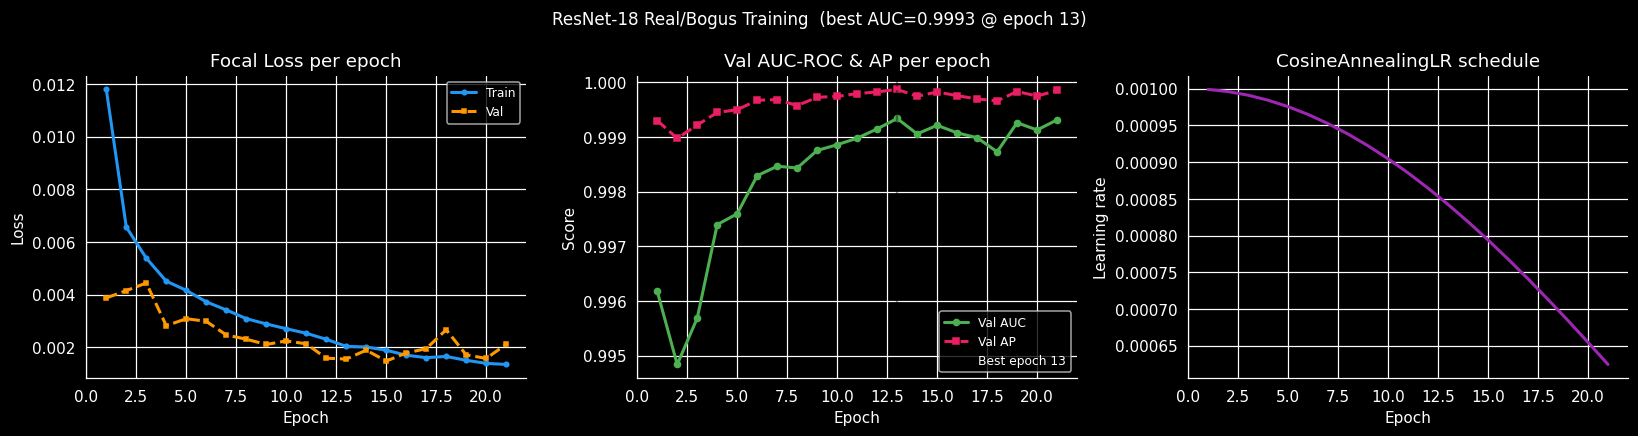

Best val AUC: 0.9993  at epoch 13


In [11]:
# Load history (either from fresh run or saved file)
hist_path = CKPT_DIR / f'{RUN_NAME}_history.json'
if history_result is not None:
    history = history_result['history']
elif hist_path.exists():
    history = json.loads(hist_path.read_text())
else:
    print('No history found — run the training cell first.')
    history = None

if history:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    epochs_x = [h['epoch'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h.get('val_loss', float('nan')) for h in history]
    val_auc    = [h['val_auc'] for h in history]
    val_ap     = [h.get('val_ap', float('nan')) for h in history]
    lrs        = [h['lr'] for h in history]

    axes[0].plot(epochs_x, train_loss, 'o-', color='#2196F3', lw=2, ms=3, label='Train')
    axes[0].plot(epochs_x, val_loss,   's--', color='#FF9800', lw=2, ms=3, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Focal Loss per epoch')
    axes[0].legend(fontsize=8)

    axes[1].plot(epochs_x, val_auc, 'o-', color='#4CAF50', lw=2, ms=4, label='Val AUC')
    axes[1].plot(epochs_x, val_ap,  's--', color='#E91E63', lw=2, ms=4, label='Val AP')
    best_epoch = max(history, key=lambda h: h['val_auc'])['epoch']
    best_auc   = max(h['val_auc'] for h in history)
    axes[1].axvline(best_epoch, color='k', linestyle='--', alpha=0.4,
                    label=f'Best epoch {best_epoch}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].set_title('Val AUC-ROC & AP per epoch')
    axes[1].legend(fontsize=8)

    axes[2].plot(epochs_x, lrs, '-', color='#9C27B0', lw=2)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning rate')
    axes[2].set_title('CosineAnnealingLR schedule')

    plt.suptitle(f'ResNet-18 Real/Bogus Training  (best AUC={best_auc:.4f} @ epoch {best_epoch})',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('../results/training_curves_resnet18_rb.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f'Best val AUC: {best_auc:.4f}  at epoch {best_epoch}')

## 5 — Quick Validation Evaluation

In [12]:
# Load best checkpoint and run on val set
ckpt_path = CKPT_DIR / f'{RUN_NAME}_best.pt'
if ckpt_path.exists():
    model_eval = RealBogusResNet18()
    ckpt = load_checkpoint(model_eval, ckpt_path)
    model_eval = model_eval.to(DEVICE)
    val_stats = evaluate_rb(model_eval, val_loader, DEVICE)
    print(f'Val AUC:  {val_stats["auc"]:.4f}')
    print(f'Val AP:   {val_stats["ap"]:.4f}')
    print(f'Loaded from epoch {ckpt.get("epoch", "?")}')
else:
    print('No checkpoint found. Run training first.')

Loaded checkpoint from ../checkpoints/resnet18_rb_best.pt (epoch 13)


Val AUC:  0.9993
Val AP:   0.9999
Loaded from epoch 13


## 6 — Checkpoint Verification

In [13]:
import os
ckpt_path = CKPT_DIR / f'{RUN_NAME}_best.pt'
if ckpt_path.exists():
    size_mb = os.path.getsize(ckpt_path) / 1e6
    ckpt = torch.load(ckpt_path, map_location='cpu')
    print(f'Checkpoint: {ckpt_path}')
    print(f'File size:  {size_mb:.1f} MB')
    print(f'Keys:       {list(ckpt.keys())}')
    print(f'Epoch:      {ckpt.get("epoch", "?")}')  
    print(f'Val AUC:    {ckpt.get("val_auc", "?")}')
    print(f'Config:     {ckpt.get("config", {})}')
else:
    print('No checkpoint yet.')

Checkpoint: ../checkpoints/resnet18_rb_best.pt
File size:  134.2 MB
Keys:       ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_auc', 'config']
Epoch:      13
Val AUC:    0.9993396791585165
Config:     {'task': 'real_bogus', 'lr': 0.001, 'weight_decay': 0.0001}


## 7 — Summary

In [14]:
print('='*60)
print('  STAGE 8 — TRAINING SUMMARY')
print('='*60)

print('\nPipeline:')
print('  src/train.py  → train() → train_epoch() + evaluate_rb()')
print('  src/losses.py → FocalLoss(alpha=0.25, gamma=2.0)')
print('  src/dataset.py → WeightedRandomSampler  (class imbalance, spec §7)')

print('\nHyperparameters:')
print('  Optimiser  : AdamW (lr=1e-3, weight_decay=1e-4)')
print('  Scheduler  : CosineAnnealingLR (T_max=50)')
print('  Batch size : 64')
print('  Precision  : FP16 (torch.cuda.amp)')
print('  Grad clip  : 1.0')
print('  Patience   : 8 epochs (early stopping)')

print('\nOutputs:')
print('  checkpoints/resnet18_rb_best.pt    ← best val AUC weights')
print('  checkpoints/resnet18_rb_history.json ← per-epoch metrics')
print('  results/training_curves_resnet18_rb.png')

print('\nNext step: Stage 9 — Evaluation (notebooks/05_evaluation.ipynb)')

  STAGE 8 — TRAINING SUMMARY

Pipeline:
  src/train.py  → train() → train_epoch() + evaluate_rb()
  src/losses.py → FocalLoss(alpha=0.25, gamma=2.0)
  src/dataset.py → WeightedRandomSampler  (class imbalance, spec §7)

Hyperparameters:
  Optimiser  : AdamW (lr=1e-3, weight_decay=1e-4)
  Scheduler  : CosineAnnealingLR (T_max=50)
  Batch size : 64
  Precision  : FP16 (torch.cuda.amp)
  Grad clip  : 1.0
  Patience   : 8 epochs (early stopping)

Outputs:
  checkpoints/resnet18_rb_best.pt    ← best val AUC weights
  checkpoints/resnet18_rb_history.json ← per-epoch metrics
  results/training_curves_resnet18_rb.png

Next step: Stage 9 — Evaluation (notebooks/05_evaluation.ipynb)
